# CoMM: EEG and diffusion-prior fusion

This report evaluates whether a diffusion-prior image latent adds useful information to an EEG representation for image retrieval. The hypothesis is that EEG contains neural information about the viewed image, while the prior can convert that representation into a more image-like latent. CoMM fuses both representations into a joint prototype.

The maintained comparison is against the ground-truth image latent. The earlier generated-branch metrics are retained as diagnostics, but are not the primary result.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
RUN_DIR = PROJECT_ROOT / 'experiments/comm/20260901_084821/train_comm-20260901_084858/version_0'
METRICS_PATH = RUN_DIR / 'test/test_metrics.csv'
CONFIG_PATH = RUN_DIR / 'test/evaluation_config.yaml'
metrics = pd.read_csv(METRICS_PATH).set_index('metric')['value']
evaluation_config = yaml.safe_load(CONFIG_PATH.read_text())
assert {'acc_eeg_to_target_img', 'acc_generated_img_to_target_img', 'acc_proto_to_target_img'} <= set(metrics.index)
metrics.loc[['acc_eeg_to_target_img', 'acc_generated_img_to_target_img', 'acc_proto_to_target_img']]

metric
acc_eeg_to_target_img              0.250
acc_generated_img_to_target_img    0.095
acc_proto_to_target_img            0.190
Name: value, dtype: float64

## Experimental pipeline

| Stage | Representation | Role |
|---|---|---|
| EEG alignment | aligned EEG latent | Maps EEG into the image-latent space |
| Diffusion prior | generated `clip_vith14` latent | Produces an image-like prediction from EEG |
| CoMM | EEG + generated-prior prototype | Fuses the two modalities |
| Retrieval | top-1 against target `clip_vith14` latent | Tests correspondence to the viewed image |

CoMM was trained using cached target image latents for efficiency. During evaluation, the image branch is switched to latents generated by the frozen diffusion prior. The target latent is retained separately and is used only as the retrieval reference.

## Reproducibility and checkpoint

The selected checkpoint was chosen by maximum validation `val/acc_eeg_to_img`. This is the training-time generated-branch metric; the final scientific comparison below uses ground-truth target-reference metrics.

In [2]:
selected = evaluation_config['evaluator']
prior = evaluation_config['model']
pd.Series({
    'selected checkpoint': selected['checkpoint_path'],
    'checkpoint metric': selected['checkpoint_metric'],
    'prior checkpoint': prior['prior_checkpoint_path'],
    'prior image encoder': prior['prior_img_encoder'],
    'prior steps': prior['prior_generation_steps'],
    'prior guidance scale': prior['prior_guidance_scale'],
    'prior generation batch size': prior['prior_generation_batch_size'],
})

selected checkpoint            experiments/comm/20260901_084821/train_comm-20...
checkpoint metric                                             val/acc_eeg_to_img
prior checkpoint               experiments/eeg_prior/20260831_134809/train_ee...
prior image encoder                                                  clip_vith14
prior steps                                                                  100
prior guidance scale                                                        10.0
prior generation batch size                                                   32
dtype: object

## Primary retrieval results

These are top-1 accuracies against the ground-truth target image latent. The fused prototype is the proposed method; EEG-only and prior-only are comparison baselines.

In [3]:
primary = pd.DataFrame({
    'representation': ['EEG only', 'Generated prior only', 'Fused CoMM prototype'],
    'query_to_target_top1': [metrics['acc_eeg_to_target_img'], metrics['acc_generated_img_to_target_img'], metrics['acc_proto_to_target_img']],
    'target_to_query_top1': [metrics['acc_target_img_to_eeg'], metrics['acc_target_img_to_generated_img'], metrics['acc_target_img_to_proto']],
})
primary.style.format({'query_to_target_top1': '{:.3f}', 'target_to_query_top1': '{:.3f}'})

,representation,query_to_target_top1,target_to_query_top1
0,EEG only,0.250,0.235
1,Generated prior only,0.095,0.050
2,Fused CoMM prototype,0.190,0.145


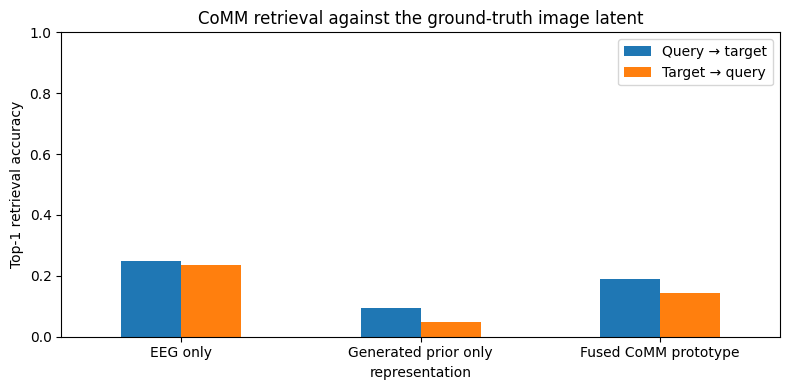

In [4]:
ax = primary.plot.bar(x='representation', y=['query_to_target_top1', 'target_to_query_top1'], figsize=(8, 4), rot=0)
ax.set_ylim(0, 1)
ax.set_ylabel('Top-1 retrieval accuracy')
ax.set_title('CoMM retrieval against the ground-truth image latent')
ax.legend(['Query → target', 'Target → query'])
plt.tight_layout()

## Interpretation

The EEG-only representation reaches `0.250` query-to-target top-1 accuracy. The generated prior alone reaches `0.095`, while the fused CoMM prototype reaches `0.190`. Thus, this run does not support the hypothesis that the generated prior improves retrieval when fused with EEG: fusion is below the EEG-only baseline.

The legacy generated-branch diagnostics are also available in the CSV, including `acc_eeg_to_proto=0.610` and `acc_proto_to_img=0.965`. They measure agreement with the generated prior branch, not retrieval against the ground-truth image, so they should not be used as the primary fusion result.